# Week 2 Internship Task
# Deep Exploratory Data Analysis & Feature Engineering

## Steel Industry Energy Consumption Dataset

### Prepared by:
**Ayesha Qamar**

---

## Project Overview

The objective of this project is to perform a comprehensive Exploratory Data Analysis (EDA) and Feature Engineering on the Steel Industry Energy Consumption dataset. The dataset contains real-world energy consumption records collected from a steel manufacturing plant, including electricity usage, power factors, load types, and timestamp information.

Exploratory Data Analysis is an essential step in every machine learning project because it helps us understand the dataset, identify patterns, detect data quality issues, discover relationships between variables, and create meaningful features that improve model performance.

In this notebook, we will:
- Understand the dataset structure
- Examine data quality
- Engineer new time-based and domain-specific features
- Detect outliers
- Explore relationships between variables
- Visualize important trends
- Summarize key findings that will guide the machine learning models developed in Part 2.

# Importing Required Libraries 

Before starting the analysis, we first import the Python libraries required throughout this notebook.

Each library serves a specific purpose:

- **Pandas** is used for loading and manipulating tabular data.
- **NumPy** provides numerical and mathematical operations.
- **Matplotlib** is used to create basic visualizations.
- **Seaborn** helps generate attractive statistical plots.
- **Warnings** is used to suppress unnecessary warning messages for cleaner notebook output.

As all required libraries at the beginning keeps the notebook organized and ensures all tools are readily available for the analysis.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("Steel_industry_data.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [4]:
print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")
df.columns
df.info()
df.describe().T

Number of Rows    : 35040
Number of Columns : 11
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                        

,count,mean,std,min,25%,50%,75%,max
Usage_kWh,35040.0,27.386892,33.444380,0.0,3.20,4.57,51.2375,157.18
Lagging_Current_Reactive.Power_kVarh,35040.0,13.035384,16.306000,0.0,2.30,5.00,22.6400,96.91
Leading_Current_Reactive_Power_kVarh,35040.0,3.870949,7.424463,0.0,0.00,0.00,2.0900,27.76
CO2(tCO2),35040.0,0.011524,0.016151,0.0,0.00,0.00,0.0200,0.07
Lagging_Current_Power_Factor,35040.0,80.578056,18.921322,0.0,63.32,87.96,99.0225,100.00
Leading_Current_Power_Factor,35040.0,84.367870,30.456535,0.0,99.70,100.00,100.0000,100.00
NSM,35040.0,42750.000000,24940.534317,0.0,21375.00,42750.00,64125.0000,85500.00


In [5]:
df.tail()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
35035,31/12/2018 23:00,3.85,4.86,0.00,0.0,62.10,100.00,82800,Weekday,Monday,Light_Load
35036,31/12/2018 23:15,3.74,3.74,0.00,0.0,70.71,100.00,83700,Weekday,Monday,Light_Load
35037,31/12/2018 23:30,3.78,3.17,0.07,0.0,76.62,99.98,84600,Weekday,Monday,Light_Load
35038,31/12/2018 23:45,3.78,3.06,0.11,0.0,77.72,99.96,85500,Weekday,Monday,Light_Load
35039,31/12/2018 00:00,3.67,3.02,0.07,0.0,77.22,99.98,0,Weekday,Monday,Light_Load


# Step 1: Load the Dataset and Re-examine Its Structure

## Purpose

The first step in any data analysis project is to understand the dataset before performing any preprocessing or modeling. Examining the dataset structure helps identify the available features, data types, dataset size, and any columns that may require preprocessing. This understanding provides a strong foundation for the exploratory data analysis and feature engineering performed in the following steps.

## Observations

The dataset was successfully loaded into a Pandas DataFrame and contains **35,040 records** and **11 features**. Each record represents the energy consumption of a steel manufacturing plant measured at regular time intervals.

From the initial inspection (`head()` and `tail()`), the dataset includes information related to electricity usage, reactive power measurements, power factors, time information, and load categories.

The `info()` output shows that:

- The dataset contains **35,040 entries**, indicating a complete dataset.
- There are **11 columns** in total.
- The dataset consists of:
  - **7 numerical columns**
  - **4 object (categorical/text) columns**, including the `date` column.
- The `date` column is currently stored as an **object** rather than a datetime format, so it will need to be converted before extracting time-based features.
- The remaining numerical columns are already stored using appropriate numeric data types (`float64` and `int64`).

The descriptive statistics provide an initial understanding of the numerical variables. For example, `Usage_kWh` has an average value of approximately **27.39 kWh**, with values ranging from **0** to **157.18 kWh**, indicating considerable variation in electricity consumption. Similarly, the power-related variables show a wide range of values, suggesting that the plant operates under different load conditions throughout the year.

Overall, the dataset appears well-structured and suitable for further exploratory analysis and feature engineering.

In [6]:

df["date"] = pd.to_datetime(df["date"], dayfirst=True)

print("Date column converted successfully.")
print("\nUpdated Data Type:")
print(df["date"].dtype)
df["Hour"] = df["date"].dt.hour

df["Day_of_Week_Name"] = df["date"].dt.day_name()

df["Month"] = df["date"].dt.month_name()

df["Day_Type"] = df["date"].dt.dayofweek.apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

print("New features created successfully!")

Date column converted successfully.

Updated Data Type:
datetime64[ns]
New features created successfully!


In [7]:
df[["date", "Hour", "Day_of_Week_Name", "Month", "Day_Type"]].head(10)

,date,Hour,Day_of_Week_Name,Month,Day_Type
0,2018-01-01 00:15:00,0,Monday,January,Weekday
1,2018-01-01 00:30:00,0,Monday,January,Weekday
2,2018-01-01 00:45:00,0,Monday,January,Weekday
3,2018-01-01 01:00:00,1,Monday,January,Weekday
4,2018-01-01 01:15:00,1,Monday,January,Weekday
5,2018-01-01 01:30:00,1,Monday,January,Weekday
6,2018-01-01 01:45:00,1,Monday,January,Weekday
7,2018-01-01 02:00:00,2,Monday,January,Weekday
8,2018-01-01 02:15:00,2,Monday,January,Weekday
9,2018-01-01 02:30:00,2,Monday,January,Weekday


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   date                                  35040 non-null  datetime64[ns]
 1   Usage_kWh                             35040 non-null  float64       
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64       
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64       
 4   CO2(tCO2)                             35040 non-null  float64       
 5   Lagging_Current_Power_Factor          35040 non-null  float64       
 6   Leading_Current_Power_Factor          35040 non-null  float64       
 7   NSM                                   35040 non-null  int64         
 8   WeekStatus                            35040 non-null  object        
 9   Day_of_week                           35040 non-null  object        
 10

# Step 2: Convert the Date Column and Engineer Time-Based Features

## Purpose

The original `date` column was stored as an **object (text)** data type, which limits time-based analysis and cannot be directly utilized by most machine learning algorithms. Converting it to a datetime format enables us to extract meaningful temporal information that may influence energy consumption patterns.

To enrich the dataset, the following time-based features were engineered:

- **Hour** – Represents the hour of the day when the energy reading was recorded.
- **Day_of_Week_Name** – Indicates the day of the week for each observation.
- **Month** – Identifies the month in which the reading was taken.
- **Day_Type** – Classifies each observation as either a **Weekday** or **Weekend** based on the date.

These engineered features provide additional context that can help uncover daily, weekly, and seasonal energy consumption patterns during exploratory data analysis. They may also improve the predictive performance of machine learning models by allowing them to learn time-dependent behavior.

## Observations

The `date` column was successfully converted from the **object** data type to **datetime64[ns]**, making it suitable for datetime operations.

Four new features were successfully added to the dataset:

- `Hour`
- `Day_of_Week_Name`
- `Month`
- `Day_Type`

After feature engineering, the dataset now contains **15 columns**, while the total number of records remains unchanged at **35,040**, confirming that no data was lost during the transformation process.

The preview of the engineered features shows that the extracted values correctly match the original timestamps. For example, records from **1 January 2018** are correctly identified as **Monday**, belong to the month **January**, and are classified as **Weekday**. Similarly, the `Hour` feature accurately reflects the hour component of each timestamp.

These newly created features will be valuable in later stages of the analysis, particularly for identifying hourly usage trends, comparing weekdays with weekends, and examining seasonal patterns in energy consumption.

In [9]:

df["Power_Factor_Ratio"] = (
    df["Leading_Current_Power_Factor"] /
    df["Lagging_Current_Power_Factor"]
)

print("Power_Factor_Ratio feature created successfully!")
df[
    [
        "Leading_Current_Power_Factor",
        "Lagging_Current_Power_Factor",
        "Power_Factor_Ratio"
    ]
].head(10)

Power_Factor_Ratio feature created successfully!


,Leading_Current_Power_Factor,Lagging_Current_Power_Factor,Power_Factor_Ratio
0,100.0,73.21,1.365934
1,100.0,66.77,1.497679
2,100.0,70.28,1.422880
3,100.0,68.09,1.468644
4,100.0,64.72,1.545117
5,100.0,67.76,1.475797
6,100.0,65.62,1.523926
7,100.0,64.37,1.553519
8,100.0,66.94,1.493875
9,100.0,62.51,1.599744


In [10]:
df["Power_Factor_Ratio"].describe()

count    35039.000000
mean         1.173234
std          0.587466
min          0.125000
25%          1.001809
50%          1.136105
75%          1.579280
max          2.707093
Name: Power_Factor_Ratio, dtype: float64

In [11]:


print("Missing Values :", df["Power_Factor_Ratio"].isna().sum())
print("Infinite Values:", np.isinf(df["Power_Factor_Ratio"]).sum())

# Display the affected row(s)
df[df["Power_Factor_Ratio"].isna() | np.isinf(df["Power_Factor_Ratio"])]

Missing Values : 1
Infinite Values: 0


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Day_of_Week_Name,Month,Day_Type,Power_Factor_Ratio
29855,2018-11-07,0.0,0.0,0.0,0.0,0.0,0.0,0,Weekday,Wednesday,Light_Load,0,Wednesday,November,Weekday,NaN


In [12]:
df["Power_Factor_Ratio"] = df["Power_Factor_Ratio"].fillna(0)
print("Missing Values:", df["Power_Factor_Ratio"].isna().sum())

Missing Values: 0


# Step 3: Create the Power Factor Ratio Feature

## Purpose

To capture the relationship between the leading and lagging power factors, a new feature named **Power_Factor_Ratio** was created by dividing the leading power factor by the lagging power factor.

This engineered feature combines two related electrical measurements into a single variable, which may help identify operational conditions associated with different levels of energy consumption.

## Observations

The new feature was created successfully and added to the dataset. The ratio ranges from approximately **0.13** to **2.71**, with an average value of **1.17**.

During feature creation, one missing value was generated because a single record contained zero values for both the leading and lagging power factors, resulting in an undefined (0/0) division. Since this record represents no power usage, the missing ratio was replaced with **0**, ensuring the dataset contains no missing values before further analysis.

In [13]:
usage_threshold = df["Usage_kWh"].quantile(0.75)

print(f"75th Percentile of Usage_kWh: {usage_threshold:.4f} kWh")

df["High_Load"] = (df["Usage_kWh"] > usage_threshold).astype(int)

print("High_Load feature created successfully!")

df[["Usage_kWh", "High_Load"]].head(10)

print(df["High_Load"].value_counts())

print("\nPercentage Distribution:")

print(
    (df["High_Load"].value_counts(normalize=True) * 100)
    .round(2)
    .astype(str) + "%"
)

75th Percentile of Usage_kWh: 51.2375 kWh
High_Load feature created successfully!
High_Load
0    26280
1     8760
Name: count, dtype: int64

Percentage Distribution:
High_Load
0    75.0%
1    25.0%
Name: proportion, dtype: object


# Step 4: Create the High_Load Feature

## Purpose

To identify periods of high energy demand, a new binary feature called **High_Load** was created using the 75th percentile of the `Usage_kWh` column as the threshold.

Records with energy consumption above the 75th percentile were assigned a value of **1 (High Load)**, while all remaining records were assigned **0 (Normal Load)**.

## Observations

The calculated 75th percentile of `Usage_kWh` is **51.2375 kWh**.

Using this threshold:
- **26,280 observations (75%)** were classified as **Normal Load (0)**.
- **8,760 observations (25%)** were classified as **High Load (1)**.

The resulting distribution matches the expected 75:25 split, confirming that the feature was created correctly.

> **Note:** Since `High_Load` is derived directly from the target variable (`Usage_kWh`), it introduces **target leakage**. Therefore, it will be used only for exploratory analysis and will be removed before training the regression models in Part 2.

Q1           : 3.20
Q3           : 51.24
IQR          : 48.04
Lower Bound  : -68.86
Upper Bound  : 123.29
Number of Outliers: 328

Percentage of Outliers:
0.94%


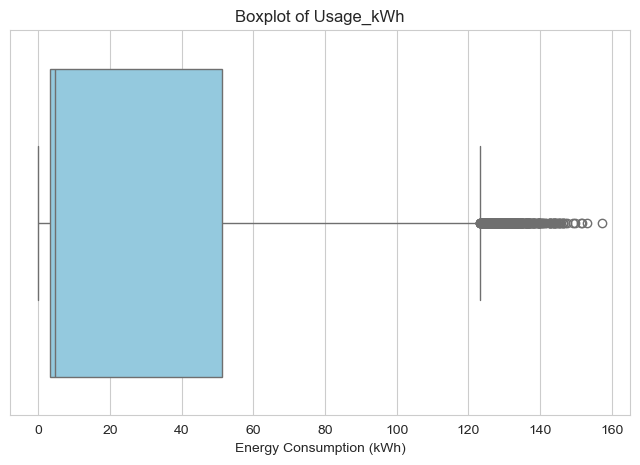

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Day_of_Week_Name,Month,Day_Type,Power_Factor_Ratio,High_Load
140,2018-01-02 11:15:00,128.52,70.85,0.0,0.0,87.57,100.0,40500,Weekday,Tuesday,Maximum_Load,11,Tuesday,January,Weekday,1.141944,1
141,2018-01-02 11:30:00,144.47,78.48,0.0,0.0,87.87,100.0,41400,Weekday,Tuesday,Maximum_Load,11,Tuesday,January,Weekday,1.138045,1
143,2018-01-02 12:00:00,123.30,66.06,0.0,0.0,88.15,100.0,43200,Weekday,Tuesday,Maximum_Load,12,Tuesday,January,Weekday,1.134430,1
150,2018-01-02 13:45:00,124.45,49.79,0.0,0.0,92.85,100.0,49500,Weekday,Tuesday,Medium_Load,13,Tuesday,January,Weekday,1.077006,1
153,2018-01-02 14:30:00,129.10,53.50,0.0,0.0,92.38,100.0,52200,Weekday,Tuesday,Medium_Load,14,Tuesday,January,Weekday,1.082485,1
155,2018-01-02 15:00:00,143.89,60.91,0.0,0.0,92.09,100.0,54000,Weekday,Tuesday,Medium_Load,15,Tuesday,January,Weekday,1.085894,1
157,2018-01-02 15:30:00,141.44,62.57,0.0,0.0,91.45,100.0,55800,Weekday,Tuesday,Medium_Load,15,Tuesday,January,Weekday,1.093494,1
159,2018-01-02 16:00:00,129.31,61.16,0.0,0.0,90.40,100.0,57600,Weekday,Tuesday,Medium_Load,16,Tuesday,January,Weekday,1.106195,1
160,2018-01-02 16:15:00,136.44,56.77,0.0,0.0,92.33,100.0,58500,Weekday,Tuesday,Medium_Load,16,Tuesday,January,Weekday,1.083072,1
162,2018-01-02 16:45:00,147.46,65.27,0.0,0.0,91.44,100.0,60300,Weekday,Tuesday,Medium_Load,16,Tuesday,January,Weekday,1.093613,1


In [14]:
Q1 = df["Usage_kWh"].quantile(0.25)
Q3 = df["Usage_kWh"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

print(f"Q1           : {Q1:.2f}")
print(f"Q3           : {Q3:.2f}")
print(f"IQR          : {IQR:.2f}")
print(f"Lower Bound  : {lower_bound:.2f}")
print(f"Upper Bound  : {upper_bound:.2f}")

outliers = df[
    (df["Usage_kWh"] < lower_bound) |
    (df["Usage_kWh"] > upper_bound)
]

print(f"Number of Outliers: {len(outliers)}")

print("\nPercentage of Outliers:")
print(f"{(len(outliers)/len(df))*100:.2f}%")

plt.figure(figsize=(8,5))

sns.boxplot(x=df["Usage_kWh"], color="skyblue")

plt.title("Boxplot of Usage_kWh")
plt.xlabel("Energy Consumption (kWh)")

plt.show()

outliers.head(10)

# Step 5: Detect Outliers in `Usage_kWh`

## Purpose

Outlier detection helps identify unusually high or low energy consumption values that may influence model performance. In this step, the Interquartile Range (IQR) method was used to detect outliers in the `Usage_kWh` column, followed by a boxplot to visualize their distribution.

## Observations

The calculated quartiles are:

- **Q1:** 3.20 kWh
- **Q3:** 51.24 kWh
- **IQR:** 48.04 kWh

Using the IQR method, the acceptable range for `Usage_kWh` is **-68.86 kWh to 123.29 kWh**.

A total of **328 observations (0.94%)** were identified as outliers. The boxplot confirms that these outliers occur on the higher end of the energy consumption distribution.

Since the dataset represents real industrial operations, these high values most likely correspond to periods of increased production rather than data entry errors. Therefore, the outliers will be retained for further analysis and model training.

Numerical Features:
['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'Hour', 'Power_Factor_Ratio', 'High_Load']


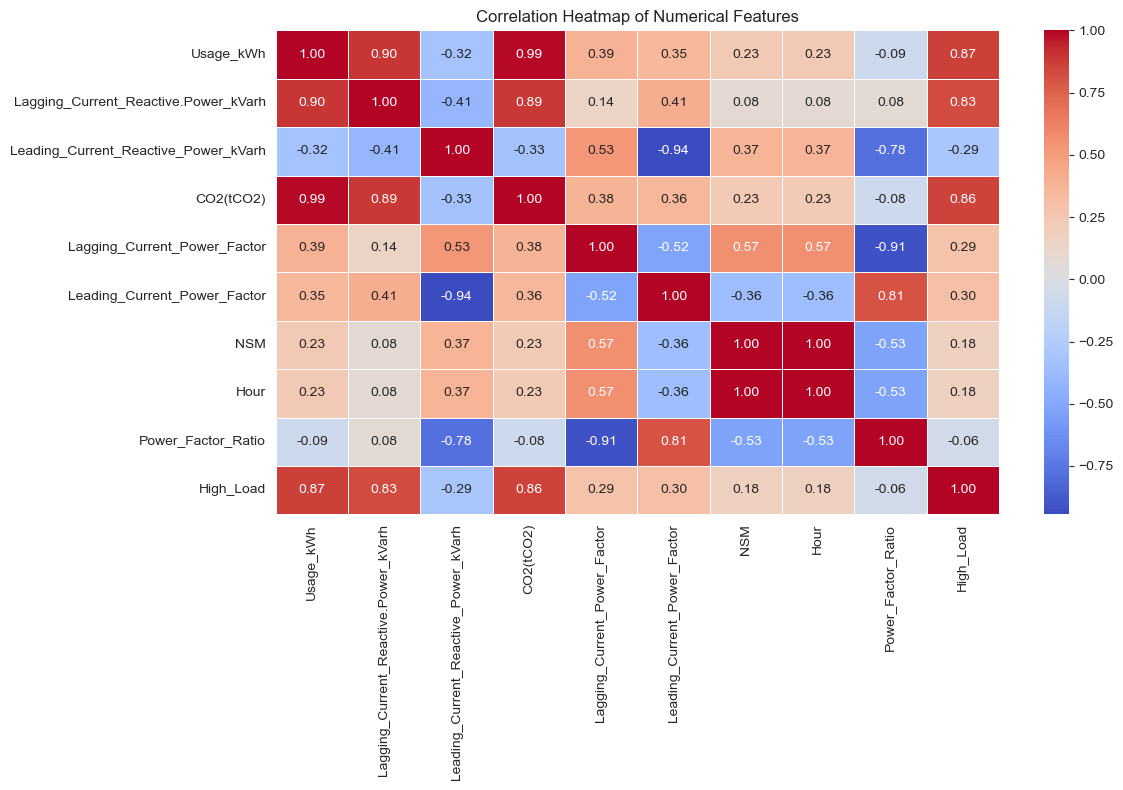

In [15]:
numerical_df = df.select_dtypes(include=["number"])

print("Numerical Features:")
print(numerical_df.columns.tolist())

plt.figure(figsize=(12, 8))

sns.heatmap(
    numerical_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()

plt.show()

In [18]:
correlation = numerical_df.corr()["Usage_kWh"].drop("Usage_kWh")

# Remove target-derived feature
correlation = correlation.drop("High_Load")

top3 = correlation.abs().sort_values(ascending=False).head(3)

top3_df = pd.DataFrame({
    "Feature": top3.index,
    "Correlation with Usage_kWh": correlation[top3.index].values
})

top3_df

,Feature,Correlation with Usage_kWh
0,CO2(tCO2),0.98818
1,Lagging_Current_Reactive.Power_kVarh,0.89615
2,Lagging_Current_Power_Factor,0.38596


In [17]:
correlation.sort_values(key=abs, ascending=False)

CO2(tCO2)                               0.988180
Lagging_Current_Reactive.Power_kVarh    0.896150
High_Load                               0.867840
Lagging_Current_Power_Factor            0.385960
Leading_Current_Power_Factor            0.353566
Leading_Current_Reactive_Power_kVarh   -0.324922
NSM                                     0.234610
Hour                                    0.234175
Power_Factor_Ratio                     -0.090041
Name: Usage_kWh, dtype: float64

# Step 6: Correlation Analysis

## Purpose

Correlation analysis was performed to examine the relationships between numerical variables and identify the features most strongly associated with energy consumption (`Usage_kWh`). A correlation heatmap was used to visualize these relationships, followed by ranking the features based on their correlation with the target variable.

## Observations

The heatmap shows varying levels of positive and negative correlation among the numerical features.

The three independent features most strongly correlated with `Usage_kWh` are:

1. **CO2(tCO2)** (Correlation ≈ **0.99**)
2. **Lagging_Current_Reactive.Power_kVarh** (Correlation ≈ **0.90**)
3. **Lagging_Current_Power_Factor** (Correlation ≈ **0.39**)

`CO2(tCO2)` has an extremely strong positive correlation with energy consumption, indicating that higher electricity usage is associated with higher carbon emissions. Similarly, lagging reactive power shows a strong positive relationship with energy consumption.

The engineered feature `High_Load` was excluded from the ranking because it was created directly from the target variable (`Usage_kWh`) and therefore introduces target leakage.

Load_Type
Light_Load       8.626207
Medium_Load     38.445394
Maximum_Load    59.265314
Name: Usage_kWh, dtype: float64


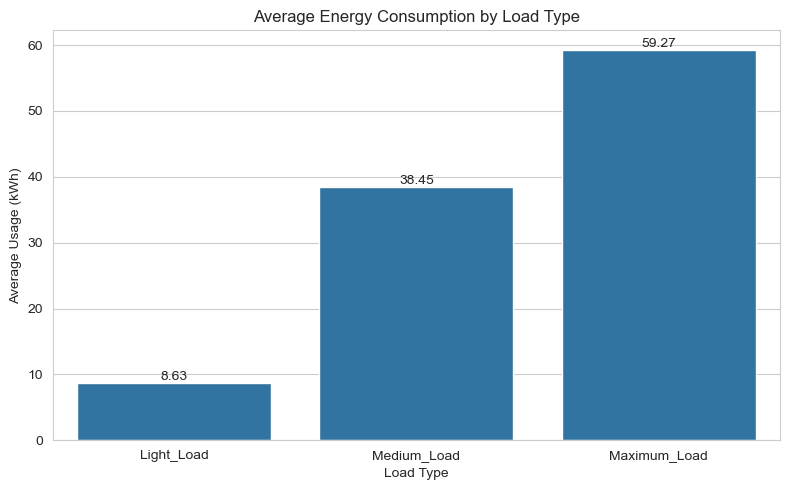

In [21]:
avg_load = (
    df.groupby("Load_Type")["Usage_kWh"]
      .mean()
      .sort_values()
)

print(avg_load)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=df,
    x="Load_Type",
    y="Usage_kWh",
    estimator="mean",
    errorbar=None,
    order=["Light_Load", "Medium_Load", "Maximum_Load"]
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.title("Average Energy Consumption by Load Type")
plt.xlabel("Load Type")
plt.ylabel("Average Usage (kWh)")

plt.tight_layout()
plt.show()

# Step 7: Average Energy Consumption by Load Type

## Purpose

This analysis compares the average energy consumption across different operating load conditions (`Light_Load`, `Medium_Load`, and `Maximum_Load`). It helps us understand how the plant's energy usage changes under different production levels.

## Observations

The average energy consumption for each load type is:

- **Light_Load:** 8.63 kWh
- **Medium_Load:** 38.45 kWh
- **Maximum_Load:** 59.27 kWh

The bar chart shows a clear upward trend in energy consumption as the load level increases. `Maximum_Load` has the highest average energy usage, while `Light_Load` has the lowest. This indicates a strong relationship between the plant's operating load and electricity consumption, suggesting that production intensity is a major factor influencing energy demand.

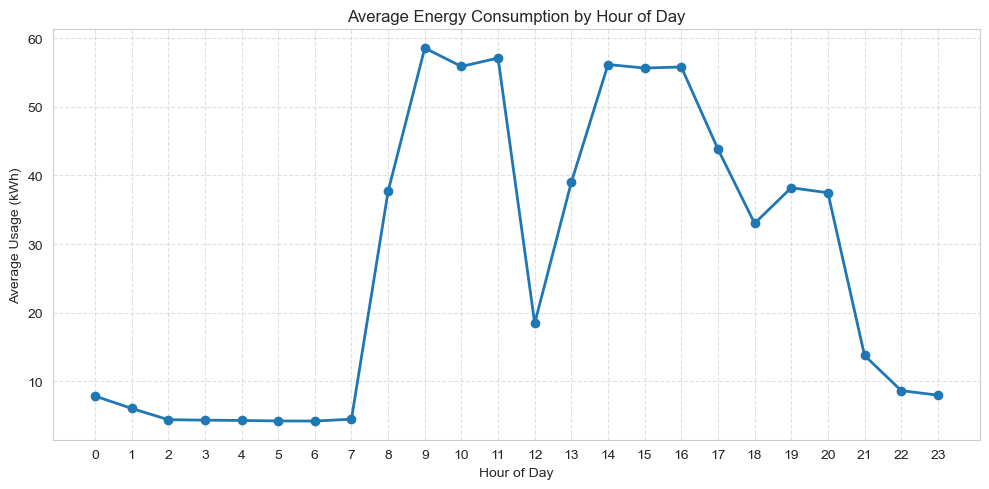

Peak Energy Consumption
Hour: 9:00
Average Usage: 58.55 kWh

Lowest Energy Consumption
Hour: 6:00
Average Usage: 4.22 kWh


In [22]:
hourly_usage = (
    df.groupby("Hour")["Usage_kWh"]
      .mean()
      .reset_index()
)

hourly_usage
plt.figure(figsize=(10,5))

plt.plot(
    hourly_usage["Hour"],
    hourly_usage["Usage_kWh"],
    marker="o",
    linewidth=2
)

plt.title("Average Energy Consumption by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Usage (kWh)")
plt.xticks(range(24))
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

peak_hour = hourly_usage.loc[hourly_usage["Usage_kWh"].idxmax()]
lowest_hour = hourly_usage.loc[hourly_usage["Usage_kWh"].idxmin()]

print("Peak Energy Consumption")
print(f"Hour: {int(peak_hour['Hour'])}:00")
print(f"Average Usage: {peak_hour['Usage_kWh']:.2f} kWh\n")

print("Lowest Energy Consumption")
print(f"Hour: {int(lowest_hour['Hour'])}:00")
print(f"Average Usage: {lowest_hour['Usage_kWh']:.2f} kWh")

# Step 8: Analyze Energy Consumption by Hour of Day

## Purpose

This analysis examines how the average energy consumption changes throughout the day. By grouping the data by hour, we can identify peak operating hours and periods of low energy demand.

## Observations

The line chart shows clear hourly variations in energy consumption throughout the day.

- The **highest average energy consumption** occurs at **9:00 AM**, with an average usage of **58.55 kWh**.
- The **lowest average energy consumption** occurs at **6:00 AM**, with an average usage of **4.22 kWh**.

Energy consumption remains relatively low during the early morning hours before increasing sharply between **8:00 AM and 11:00 AM**, suggesting the beginning of major production activities. A noticeable drop is observed around **12:00 PM**, followed by another period of high energy usage during the afternoon. Consumption gradually decreases during the evening and reaches its lowest levels again at night.

These patterns indicate that the plant follows a structured daily operating schedule, with energy demand closely aligned with production activities.

# Step 9: EDA Summary

## Data Quality Issues

The dataset contains **35,040 records** with no duplicate entries and almost no missing values. During feature engineering, one missing value appeared in the `Power_Factor_Ratio` column because one row had a lagging power factor of **0**, causing a division-by-zero situation. The `Usage_kWh` variable contains **328 outliers (0.94%)** identified using the IQR method. Since these values likely represent periods of high industrial activity rather than data errors, they were retained for further analysis.

## Top Correlated Features

Correlation analysis showed that the features most strongly related to `Usage_kWh` are:

- **CO2(tCO2)** (Correlation = **0.99**)
- **Lagging_Current_Reactive.Power_kVarh** (Correlation = **0.90**)
- **Lagging_Current_Power_Factor** (Correlation = **0.39**)

These features have the strongest relationship with energy consumption and are expected to be useful for regression modeling.

## Most Interesting Pattern

The analysis showed that energy consumption changes significantly throughout the day. The highest average energy usage occurs around **9:00 AM**, while the lowest occurs around **6:00 AM**. Energy consumption is also much higher during **Maximum_Load** than during **Light_Load**, indicating that production load has a strong impact on electricity usage.

## Hypothesis

A possible reason for energy spikes is that heavy production machinery starts operating during working hours, especially in the morning and afternoon shifts. As production load increases, the plant requires more electricity, resulting in higher energy consumption.

In [24]:
df.to_csv("steel_energy_engineered.csv", index=False)

print("Engineered dataset saved successfully!")

Engineered dataset saved successfully!
